In [185]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import math
import seaborn as sns
import copy
import textwrap
from pyvi import ViTokenizer 
from sklearn.datasets import load_files
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, ShuffleSplit, cross_val_score
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, confusion_matrix,ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler,minmax_scale
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer,TfidfTransformer


In [186]:
df=load_files(container_path="D:\\ISE_LAB\\ML-Newbie-Training\\Week 3\\SVM\\Practice 1\\data\\news_1135",encoding="utf_8")
print(df.filenames[0])
print()
print(df.target_names[0])
print()

for i in range(0,11):
    print(f"Tong so file target {i} : {len(df.filenames[df.target==i])}")
print()
print("Tong so file :",len(df.filenames))
print()
print("Danh sách các target:")
for i, name in enumerate(df.target_names):
    print(f"  {i}: {name}")
data=copy.deepcopy(df)
print()
print(textwrap.fill(data.data[0],100))

D:\ISE_LAB\ML-Newbie-Training\Week 3\SVM\Practice 1\data\news_1135\Pháp luật\0e7537e00a4dd4c8c1b8d786858885c920311800.txt

Giải trí

Tong so file target 0 : 0
Tong so file target 1 : 196
Tong so file target 2 : 186
Tong so file target 3 : 49
Tong so file target 4 : 75
Tong so file target 5 : 140
Tong so file target 6 : 138
Tong so file target 7 : 100
Tong so file target 8 : 91
Tong so file target 9 : 52
Tong so file target 10 : 0

Tong so file : 1027

Danh sách các target:
  0: Giải trí
  1: Khoa học - Công nghệ
  2: Kinh tế
  3: Pháp luật
  4: Sức khỏe
  5: Thể thao
  6: Thời sự
  7: Tin kh†c
  8: Đời sống - Xã hội
  9: Độc giả

Dân_trí Theo trình_báo của một người sống lâu_năm trong chùa , chiều pho tượng Phật trên Chánh điện
trong chùa Nam Thiên Nhất Trụ ( chùa Một Cột ) , TPHCM , đã bị trộm đục phá , lấy sạch 70 chỉ vàng
được cất_giấu bên_trong … Đến cuối ngày 10/12 , các đơn_vị nghiệp_vụ Công_an quận Thủ_Đức và Phòng
Cảnh_sát điều_tra tội_phạm về

In [187]:
with open("D:\\ISE_LAB\\ML-Newbie-Training\\Week 3\\SVM\\Practice 1\\data\\vietnamese-stopwords.txt",encoding="utf_8") as f:
    stopwords=f.readlines()
print("\n 10 Tu STW dau tien : " , stopwords[:10])
stopwords = [x.strip() for x in stopwords]
print("\n 10 Tu STW dau tien : " , stopwords[:10])
stopwords = [x.replace(" ","_") for x in stopwords]
print("\n 10 Tu STW dau tien : " , stopwords[:10])



 10 Tu STW dau tien :  ['a lô\n', 'a ha\n', 'ai\n', 'ai ai\n', 'ai nấy\n', 'ai đó\n', 'alô\n', 'amen\n', 'anh\n', 'anh ấy\n']

 10 Tu STW dau tien :  ['a lô', 'a ha', 'ai', 'ai ai', 'ai nấy', 'ai đó', 'alô', 'amen', 'anh', 'anh ấy']

 10 Tu STW dau tien :  ['a_lô', 'a_ha', 'ai', 'ai_ai', 'ai_nấy', 'ai_đó', 'alô', 'amen', 'anh', 'anh_ấy']


In [188]:
import unicodedata,re,pandas as pd
def remov_stw(text):
    if not text:
      return ""
    text=text.lower()
    tokens = re.findall(r'\b\w+\b', text)
    tokens = [unicodedata.normalize('NFC', w) for w in tokens]
    
    filtered = [w for w in tokens if unicodedata.normalize('NFC', w) not in stopwords]
    
    return " ".join(filtered)
data.data = [remov_stw(x) for x in data.data]

In [189]:
modl_cv=CountVectorizer()
modl_tfidf=TfidfTransformer()

X_bow=modl_cv.fit_transform(data.data)
X_tfidf=modl_tfidf.fit_transform(X_bow)


print(textwrap.fill(data.data[0],100))
feature_names = modl_cv.get_feature_names_out()
df_sample = pd.DataFrame(X_bow[:7].toarray(), columns=feature_names)
display(df_sample)

i = 0
for k,v in sorted(modl_cv.vocabulary_.items(), key=lambda x: x[1], reverse=True):
    i+=1
    print(i, ": ", (k, v))
    if i > 10:
        break 
print() 
feature_names_1=modl_tfidf.get_feature_names_out()
df_spl=pd.DataFrame(X_tfidf[:7].toarray(),columns=feature_names_1)
display(df_spl)
id=0
tfidf_scores = X_tfidf[0].toarray().flatten()

word_tfidf_pairs = list(zip(feature_names, tfidf_scores))

sorted_tfidf = sorted(word_tfidf_pairs, key=lambda x: x[1], reverse=True)

print(f"Top 10 từ có TF-IDF cao nhất trong văn bản 0 :")
for i, (word, score) in enumerate(sorted_tfidf[:10], 1):
    print(f"{i}: {word} (Score: {score:.4f})")

dân_trí trình_báo sống lâu_năm chùa chiều tượng phật chánh điện chùa nam thiên trụ chùa cột tphcm
trộm đục phá sạch 70 vàng cất_giấu bên_trong 10 12 nghiệp_vụ công_an thủ_đức phòng cảnh_sát điều_tra
tội_phạm trật_tự xã_hội pc45 công_an tphcm hoàn_tất công_tác khám_nghiệm hiện_trường ghi lời_khai
nhân_chứng truy_xét vụ trộm táo_tợn xảy chùa cột đường đặng văn bi phường bình_thọ thủ_đức tphcm
thông_tin trình_báo của_ông n sống lâu_năm chùa cơ_quan công_an cất_giấu 7 vàng 70 trị_giá 200 triệu
đồng tượng phật điện dược sư chánh điện n 7 12 tượng dấu_hiệu đục phá n kiểm_tra phát_hiện vàng giấu
bên_trong lấy_mất kiểm_tra 2 tượng đàn_ông tá_hoả toàn_bộ vàng sạch n trình_báo công_an địa_phương
tiếp_nhận thông_tin lực_lượng chức_năng nhanh_chóng có_mặt tiến_hành phong_tỏa hiện_trường điều_tra
vụ_việc đăng lê


,00,000,0000,000000,000001,00001,000012,00020,00021,00022,...,ứng_dụng,ứng_lực,ứng_nghiệm,ứng_phó,ứng_trước,ứng_tuyển,ứng_tác,ứng_viên,ứng_xử,ỷ_lại
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


1 :  ('ỷ_lại', 23342)
2 :  ('ứng_xử', 23341)
3 :  ('ứng_viên', 23340)
4 :  ('ứng_tác', 23339)
5 :  ('ứng_tuyển', 23338)
6 :  ('ứng_trước', 23337)
7 :  ('ứng_phó', 23336)
8 :  ('ứng_nghiệm', 23335)
9 :  ('ứng_lực', 23334)
10 :  ('ứng_dụng', 23333)
11 :  ('ứng_cử', 23332)



,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x23333,x23334,x23335,x23336,x23337,x23338,x23339,x23340,x23341,x23342
0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.021629,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.021821,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Top 10 từ có TF-IDF cao nhất trong văn bản 0 :
1: chùa (Score: 0.4024)
2: tượng (Score: 0.3165)
3: trình_báo (Score: 0.2414)
4: vàng (Score: 0.2010)
5: phật (Score: 0.1954)
6: công_an (Score: 0.1939)
7: đục (Score: 0.1871)
8: thủ_đức (Score: 0.1808)
9: cất_giấu (Score: 0.1712)
10: cột (Score: 0.1712)


In [190]:
from sklearn.model_selection import ShuffleSplit

test_size = 0.2
# cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=0)
X_train, X_test, y_train, y_test = train_test_split( X_tfidf, data.target, test_size=test_size)

# hiển thị một số thông tin về dữ liệu 
print("Dữ liệu training: ", X_train.shape, y_train.shape)
print("Dữ liệu testing: ", X_test.shape, y_test.shape)
print("Danh sách nhãn và id tương ứng: ", [(idx, name) for idx, name in enumerate(data.target_names)] )

Dữ liệu training:  (821, 23343) (821,)
Dữ liệu testing:  (206, 23343) (206,)
Danh sách nhãn và id tương ứng:  [(0, 'Giải trí'), (1, 'Khoa học - Công nghệ'), (2, 'Kinh tế'), (3, 'Pháp luật'), (4, 'Sức khỏe'), (5, 'Thể thao'), (6, 'Thời sự'), (7, 'Tin kh†c'), (8, 'Đời sống - Xã hội'), (9, 'Độc giả')]


In [191]:
from sklearn import svm
print("- Training ...")
print("- Train size = {}".format(X_train.shape))
model = svm.SVC(kernel='linear', C=1)
model.fit(X_train, y_train)
from sklearn.metrics import accuracy_score
print("- Testing ...")
y_test_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)
print("- Train Acc = {}".format(accuracy_score(y_train, y_train_pred)))
print("- Test Acc = {}".format(accuracy_score(y_test, y_test_pred)))


- Training ...
- Train size = (821, 23343)
- Testing ...
- Train Acc = 0.9951278928136419
- Test Acc = 0.9029126213592233


In [192]:

def pred(list_t):
    # Nếu người dùng truyền vào 1 chuỗi đơn lẻ, biến nó thành list để vòng lặp chạy được
    if isinstance(list_t, str):
        list_t = [list_t]
    
    # 1. Tiền xử lý từng câu
    processed_list = []
    for t in list_t:
        van_ban_tokenized = ViTokenizer.tokenize(t) # Giờ t là string, chạy ngon!
        van_ban_cleaned = remov_stw(van_ban_tokenized)
        processed_list.append(van_ban_cleaned)
    
    # 2. Chuyển thành ma trận (Dùng transform một lần cho cả list)
    input_data_preprocessed = modl_cv.transform(processed_list)
    input_data_preprocessed = modl_tfidf.transform(input_data_preprocessed)
    
    # 3. Dự đoán
    predictions = model.predict(input_data_preprocessed)
    
    # 4. In kết quả
    print("Danh sách nhãn và id tương ứng: ", [(idx, name) for idx, name in enumerate(data.target_names)])
    for i, p in enumerate(predictions):
        print(f"Câu '{list_t[i]}':")
        print(f"  => Dự đoán: [{p}] - {data.target_names[p]}")

# Giờ gọi hàm với list 2 câu là chạy phăng phăng
pred(["Công Phượng ghi bàn cho đội tuyển bóng đá VIệt nam", "Chứng khoán đang giảm mạnh","tên lửa"])


Danh sách nhãn và id tương ứng:  [(0, 'Giải trí'), (1, 'Khoa học - Công nghệ'), (2, 'Kinh tế'), (3, 'Pháp luật'), (4, 'Sức khỏe'), (5, 'Thể thao'), (6, 'Thời sự'), (7, 'Tin kh†c'), (8, 'Đời sống - Xã hội'), (9, 'Độc giả')]
Câu 'Công Phượng ghi bàn cho đội tuyển bóng đá VIệt nam':
  => Dự đoán: [5] - Thể thao
Câu 'Chứng khoán đang giảm mạnh':
  => Dự đoán: [1] - Khoa học - Công nghệ
Câu 'tên lửa':
  => Dự đoán: [6] - Thời sự


In [193]:
from sklearn import svm
print("- Training ...")
print("- Train size = {}".format(X_train.shape))
model_ = svm.SVC(kernel='rbf', C=100,gamma=0.01)
model_.fit(X_train, y_train)
from sklearn.metrics import accuracy_score
print("- Testing ...")
y_test_pred = model_.predict(X_test)
y_train_pred = model_.predict(X_train)
print("- Train Acc = {}".format(accuracy_score(y_train, y_train_pred)))
print("- Test Acc = {}".format(accuracy_score(y_test, y_test_pred)))


- Training ...
- Train size = (821, 23343)
- Testing ...
- Train Acc = 1.0
- Test Acc = 0.9029126213592233


In [194]:

def pred(list_t):
    # Nếu người dùng truyền vào 1 chuỗi đơn lẻ, biến nó thành list để vòng lặp chạy được
    if isinstance(list_t, str):
        list_t = [list_t]
    
    # 1. Tiền xử lý từng câu
    processed_list = []
    for t in list_t:
        van_ban_tokenized = ViTokenizer.tokenize(t) # Giờ t là string, chạy ngon!
        van_ban_cleaned = remov_stw(van_ban_tokenized)
        processed_list.append(van_ban_cleaned)
    
    # 2. Chuyển thành ma trận (Dùng transform một lần cho cả list)
    input_data_preprocessed = modl_cv.transform(processed_list)
    input_data_preprocessed = modl_tfidf.transform(input_data_preprocessed)
    
    # 3. Dự đoán
    predictions = model_.predict(input_data_preprocessed)
    
    # 4. In kết quả
    print("Danh sách nhãn và id tương ứng: ", [(idx, name) for idx, name in enumerate(data.target_names)])
    for i, p in enumerate(predictions):
        print(f"Câu '{list_t[i]}':")
        print(f"  => Dự đoán: [{p}] - {data.target_names[p]}")

# Giờ gọi hàm với list 2 câu là chạy phăng phăng
pred(["Công Phượng ghi bàn cho đội tuyển bóng đá VIệt nam", "Chứng khoán đang giảm mạnh tiền tệ","tên lửa"])


Danh sách nhãn và id tương ứng:  [(0, 'Giải trí'), (1, 'Khoa học - Công nghệ'), (2, 'Kinh tế'), (3, 'Pháp luật'), (4, 'Sức khỏe'), (5, 'Thể thao'), (6, 'Thời sự'), (7, 'Tin kh†c'), (8, 'Đời sống - Xã hội'), (9, 'Độc giả')]
Câu 'Công Phượng ghi bàn cho đội tuyển bóng đá VIệt nam':
  => Dự đoán: [5] - Thể thao
Câu 'Chứng khoán đang giảm mạnh tiền tệ':
  => Dự đoán: [2] - Kinh tế
Câu 'tên lửa':
  => Dự đoán: [6] - Thời sự


- Train size = (821, 23343)
- Testing ...
- Train size = (821, 23343)
- Testing ...
- Train size = (821, 23343)
- Testing ...
- Train size = (821, 23343)
- Testing ...
- Train size = (821, 23343)
- Testing ...
- Train size = (821, 23343)
- Testing ...
- Train size = (821, 23343)
- Testing ...


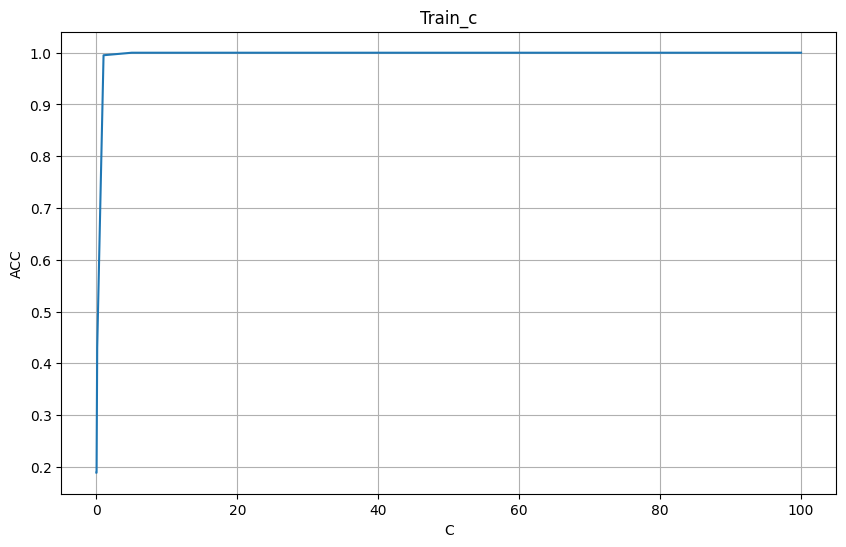

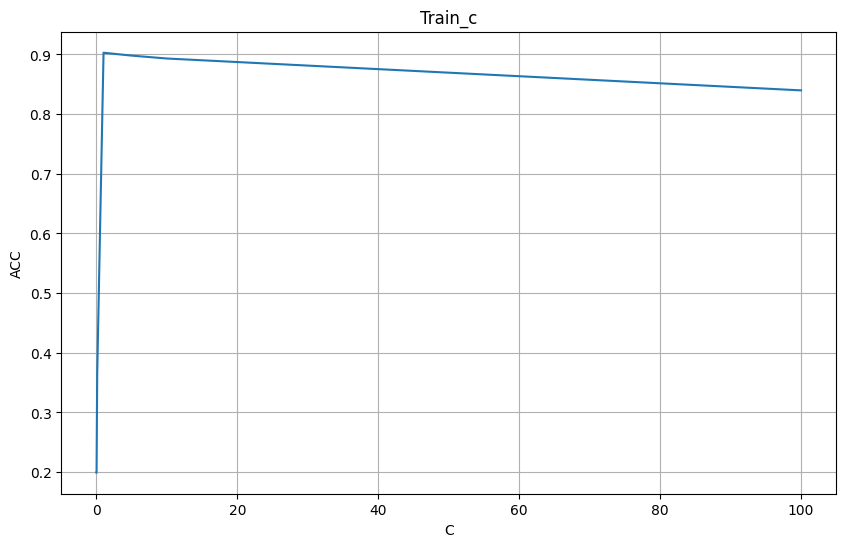

In [195]:
train_acc_arr=[]
test_acc_arr=[]
list_C = [0.001, 0.01, 0.1, 1, 5.0, 10.0, 100]
for i in list_C:
    from sklearn import svm
    print("- Train size = {}".format(X_train.shape))
    model = svm.SVC(kernel='linear', C=i)
    model.fit(X_train, y_train)
    print("- Testing ...")
    y_test_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)
    train_acc_arr.append(accuracy_score(y_train, y_train_pred))
    test_acc_arr.append(accuracy_score(y_test, y_test_pred))
    
plt.figure(figsize=(10, 6))
sns.lineplot(x=list_C, y=train_acc_arr)
plt.xlabel('C')
plt.ylabel('ACC')
plt.title('Train_c')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.lineplot(x=list_C, y=test_acc_arr)
plt.xlabel('C')
plt.ylabel('ACC')
plt.title('Train_c')
plt.grid(True)
plt.show()


In [ ]:
model=svm.SVC()
params_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
          'gamma': [0.0001, 0.001, 0.01, 0.1],
          'kernel':['linear','rbf', 'poly'] }
classifier = GridSearchCV(estimator=model, cv=5, param_grid=params_grid,
                            n_jobs=-1, scoring='accuracy')
classifier.fit(X_train.copy(), y_train)

print('Best_score :',classifier.best_score_)
print(classifier.best_estimator_)

Best modelBest_score : 0.8586844050258685
SVC(C=1, gamma=0.0001, kernel='linear')


[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
Dữ liệu training =  (1437, 64) (1437,)
Dữ liệu testing =  (360, 64) (360,)


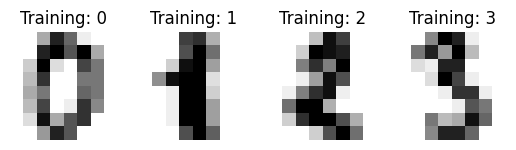

In [ ]:

# Import datasets, classifiers and performance metrics
from sklearn import datasets, metrics

# The digits dataset
digits = datasets.load_digits()
print(digits.images[0])

images_and_labels = list(zip(digits.images, digits.target))
for index, (image, label) in enumerate(images_and_labels[:4]):
    plt.subplot(2, 4, index + 1)
    plt.axis('off')
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title('Training: %i' % label)

# To apply a classifier on this data, we need to flatten the image, to
# turn the data in a (samples, feature) matrix:
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))
data=data/16.0
target = digits.target
X_train, X_test, y_train, y_test = train_test_split( data, target, test_size=test_size)

print("Dữ liệu training = ", X_train.shape, y_train.shape)
print("Dữ liệu testing = ", X_test.shape, y_test.shape)


In [201]:
print("- Training ...")
print("- Train size = {}".format(X_train.shape))
model = svm.SVC(kernel='linear', C=1)
model.fit(X_train, y_train)
print("- Testing ...")
y_test_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)
print("- Train Acc = {}".format(accuracy_score(y_train, y_train_pred)))
print("- Test Acc = {}".format(accuracy_score(y_test, y_test_pred)))


- Training ...
- Train size = (1437, 64)
- Testing ...
- Train Acc = 1.0
- Test Acc = 0.9722222222222222


In [202]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}
model=svm.SVC()
classifier = GridSearchCV(estimator=model, cv=5, param_grid=params_grid,
                            n_jobs=-1, scoring='accuracy')
classifier.fit(X_train, y_train)

print('Best_score :',classifier.best_score_)
print(classifier.best_estimator_)

Best_score : 0.9923514324428959
SVC(C=1, gamma=0.001)
